In [18]:
import torch
import numpy as np
import pandas as pd
from transformers import (
    DistilBertTokenizer, 
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report,roc_curve, auc,precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from scipy.special import softmax
import warnings
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

In [2]:
# Check available device
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    print(f"\n GPU Available: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"\n MPS (Apple Silicon GPU) Available")
    print(f"   Your M3 Mac will use GPU acceleration!")
else:
    device = torch.device("cpu")
    print(f"\n Using CPU (training will be slower)")

print(f"   Device: {device}")
print(f"   PyTorch version: {torch.__version__}")

# Check memory
if device.type == "mps":
    print(f"\n M3 Mac uses unified memory (RAM shared with GPU)")
    print(f"   Recommended batch size: 16")



 MPS (Apple Silicon GPU) Available
   Your M3 Mac will use GPU acceleration!
   Device: mps
   PyTorch version: 2.5.1

 M3 Mac uses unified memory (RAM shared with GPU)
   Recommended batch size: 16


### Loading Cleaned Data

In [3]:
print("="*80)
print("LOADING DATA")
print("="*80)

# Loading the cleaned, balanced dataset
data_path = '../data/processed/cleaned_books_balanced.csv'
df = pd.read_csv(data_path)

print(f"\n Data loaded successfully!")
print(f"   Total samples: {len(df):,}")
print(f"   Columns: {df.columns.tolist()}")


print(f"\n Genre Distribution:")
print(df['genre'].value_counts())

# Preparing features and labels
texts = df['description'].tolist()
labels = df['genre_label'].tolist()

GENRE_NAMES = sorted(df['genre'].unique())
num_labels = len(GENRE_NAMES)

print(f"\n Classification Task:")
print(f"   Number of genres: {num_labels}")
print(f"   Genres: {GENRE_NAMES}")
print(f"   Sample text length: {np.mean([len(t) for t in texts]):.0f} characters")

LOADING DATA

 Data loaded successfully!
   Total samples: 9,848
   Columns: ['title', 'description', 'genre', 'genre_label']

 Genre Distribution:
genre
Horror             1231
Romance            1231
Biography          1231
Fantasy            1231
Self-Help          1231
Mystery            1231
Fiction            1231
Science Fiction    1231
Name: count, dtype: int64

 Classification Task:
   Number of genres: 8
   Genres: ['Biography', 'Fantasy', 'Fiction', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Self-Help']
   Sample text length: 888 characters


### Train-Test Split

In [4]:
print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Spliting data 
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, 
    labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels  
)

print(f"\n Data Split Complete:")
print(f"   Training samples: {len(train_texts):,}")
print(f"   Test samples: {len(test_texts):,}")
print(f"   Split ratio: 80/20")


print(f"\n Training Set Distribution:")
train_dist = pd.Series(train_labels).value_counts().sort_index()
for genre_id, count in train_dist.items():
    print(f"   Genre {genre_id}: {count:,} samples")

print(f"\n Test Set Distribution:")
test_dist = pd.Series(test_labels).value_counts().sort_index()
for genre_id, count in test_dist.items():
    print(f"   Genre {genre_id}: {count:,} samples")

TRAIN-TEST SPLIT

 Data Split Complete:
   Training samples: 7,878
   Test samples: 1,970
   Split ratio: 80/20

 Training Set Distribution:
   Genre 0: 985 samples
   Genre 1: 985 samples
   Genre 2: 985 samples
   Genre 3: 984 samples
   Genre 4: 985 samples
   Genre 5: 985 samples
   Genre 6: 984 samples
   Genre 7: 985 samples

 Test Set Distribution:
   Genre 0: 246 samples
   Genre 1: 246 samples
   Genre 2: 246 samples
   Genre 3: 247 samples
   Genre 4: 246 samples
   Genre 5: 246 samples
   Genre 6: 247 samples
   Genre 7: 246 samples


### Tokenization

In [5]:
print("="*80)
print("TOKENIZATION")
print("="*80)

# Loading DistilBERT tokenizer
print("\n Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenization parameters
MAX_LENGTH = 256  # Maximum sequence length 

print(f"\n  Tokenization Settings:")
print(f"   Model: distilbert-base-uncased")
print(f"   Max length: {MAX_LENGTH} tokens")
print(f"   Padding: Yes")
print(f"   Truncation: Yes")

# Tokenizing training data
print(f"\n  Tokenizing training data...")
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

# Tokenizing test data
print(f" Tokenizing test data...")
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

print(f"\n Tokenization Complete!")
print(f"   Training tokens shape: {train_encodings['input_ids'].shape}")
print(f"   Test tokens shape: {test_encodings['input_ids'].shape}")

#  Examples of  tokenization
print(f"\n Example Tokenization:")
example_text = train_texts[0][:100]
example_tokens = tokenizer.tokenize(example_text)
print(f"   Original text: {example_text}...")
print(f"   Number of tokens: {len(example_tokens)}")
print(f"   First 10 tokens: {example_tokens[:10]}")

TOKENIZATION

 Loading DistilBERT tokenizer...

  Tokenization Settings:
   Model: distilbert-base-uncased
   Max length: 256 tokens
   Padding: Yes
   Truncation: Yes

  Tokenizing training data...
 Tokenizing test data...

 Tokenization Complete!
   Training tokens shape: torch.Size([7878, 256])
   Test tokens shape: torch.Size([1970, 256])

 Example Tokenization:
   Original text: Martha Stewart is an undeniable force in the business world. One of the world's greatest entrepreneu...
   Number of tokens: 25
   First 10 tokens: ['martha', 'stewart', 'is', 'an', 'und', '##enia', '##ble', 'force', 'in', 'the']


### Creating Dataset Class

In [6]:
print("="*80)
print("CREATING PYTORCH DATASETS")
print("="*80)

class BookGenreDataset(torch.utils.data.Dataset):
    """
    Custom Dataset for book genre classification
    """
    
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    
    def __getitem__(self, idx):
        # Get one sample
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

# Creating dataset objects
train_dataset = BookGenreDataset(train_encodings, train_labels)
test_dataset = BookGenreDataset(test_encodings, test_labels)

print(f"\n Datasets Created:")
print(f"   Training dataset: {len(train_dataset):,} samples")
print(f"   Test dataset: {len(test_dataset):,} samples")

# Testing dataset access
print(f"\n Sample Data Point:")
sample = train_dataset[0]
print(f"   Keys: {sample.keys()}")
print(f"   Input IDs shape: {sample['input_ids'].shape}")
print(f"   Label: {sample['labels'].item()} (Genre: {GENRE_NAMES[sample['labels'].item()]})")

CREATING PYTORCH DATASETS

 Datasets Created:
   Training dataset: 7,878 samples
   Test dataset: 1,970 samples

 Sample Data Point:
   Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
   Input IDs shape: torch.Size([256])
   Label: 7 (Genre: Self-Help)


### Load DistilBERT Model

In [7]:
print("="*80)
print("LOADING DISTILBERT MODEL")
print("="*80)


# Loading model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

# Moving model to device (MPS)
model = model.to(device)

print(f"\n Model Loaded Successfully!")
print(f"   Model: DistilBERT-base-uncased")
print(f"   Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"   Number of output classes: {num_labels}")
print(f"   Device: {device}")

# Model architecture
print(f"\n Model Architecture:")
print(f"   - DistilBERT base (6 layers)")
print(f"   - Hidden size: 768")
print(f"   - Classification head: 768 → {num_labels}")

LOADING DISTILBERT MODEL


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Model Loaded Successfully!
   Model: DistilBERT-base-uncased
   Number of parameters: 66,959,624
   Trainable parameters: 66,959,624
   Number of output classes: 8
   Device: mps

 Model Architecture:
   - DistilBERT base (6 layers)
   - Hidden size: 768
   - Classification head: 768 → 8


### Defining  Training Arguments

In [8]:
print("="*80)
print("TRAINING CONFIGURATION")
print("="*80)

# Estimating training time
samples_per_epoch = len(train_dataset)
batch_size = 16
num_epochs = 3
steps_per_epoch = samples_per_epoch // batch_size

print(f"\n Training Time Estimation (M3 Mac with MPS):")
print(f"   Samples per epoch: {samples_per_epoch:,}")
print(f"   Batch size: {batch_size}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Number of epochs: {num_epochs}")
print(f"   Estimated time per epoch: ~6-10 minutes")
print(f"   Total estimated time: ~20-30 minutes")

# Training arguments
training_args = TrainingArguments(
    output_dir='./results/distilbert',          # Where to save model
    num_train_epochs=num_epochs,                 # Number of epochs
    per_device_train_batch_size=batch_size,      # Batch size for training
    per_device_eval_batch_size=batch_size,       # Batch size for evaluation
    learning_rate=5e-5,                          # Learning rate
    weight_decay=0.01,                           # Regularization
    warmup_steps=100,                            # Gradual learning rate warmup
    logging_dir='./logs/distilbert',             # Logging directory
    logging_steps=50,                            # Logging every 50 steps
    eval_strategy="epoch",                 # Evaluating after each epoch
    save_strategy="epoch",                       # Saving after each epoch
    load_best_model_at_end=True,                 # Loading best model at end
    metric_for_best_model="accuracy",            # Metric to determine best model
    save_total_limit=2,                          # Only keeping 2 best checkpoints
    report_to="none",                            
    seed=42,                                     # Random seed
    fp16=False,                                  
)

print(f"\nTraining Configuration:")
print(f"   Learning rate: {training_args.learning_rate}")
print(f"   Batch size: {training_args.per_device_train_batch_size}")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Weight decay: {training_args.weight_decay}")
print(f"   Warmup steps: {training_args.warmup_steps}")
print(f"   Evaluation: Every epoch")
print(f"   Saveing  Best 2 models only")

TRAINING CONFIGURATION

 Training Time Estimation (M3 Mac with MPS):
   Samples per epoch: 7,878
   Batch size: 16
   Steps per epoch: 492
   Number of epochs: 3
   Estimated time per epoch: ~6-10 minutes
   Total estimated time: ~20-30 minutes

Training Configuration:
   Learning rate: 5e-05
   Batch size: 16
   Epochs: 3
   Weight decay: 0.01
   Warmup steps: 100
   Evaluation: Every epoch
   Saveing  Best 2 models only


### Defining Metrics Function

In [9]:
print("="*80)
print("DEFINING EVALUATION METRICS")
print("="*80)

def compute_metrics(eval_pred):
    """
    Compute metrics during training
    """
    predictions, labels = eval_pred
    
    # Getting predicted class (argmax of logits)
    predictions = np.argmax(predictions, axis=1)
    
    # Calculating metrics
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, 
        predictions, 
        average='weighted'
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("\n Metrics Function Defined:")
print("   - Accuracy")
print("   - Precision (weighted)")
print("   - Recall (weighted)")
print("   - F1-Score (weighted)")

DEFINING EVALUATION METRICS

 Metrics Function Defined:
   - Accuracy
   - Precision (weighted)
   - Recall (weighted)
   - F1-Score (weighted)


### Creating Trainer  and Starting  Training 

In [10]:
print("="*80)
print("INITIALIZING TRAINER")
print("="*80)

# Creating Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print(f"\n Trainer Initialized!")
print(f"   Model: DistilBERT")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Validation samples: {len(test_dataset):,}")

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)


import time
start_time = time.time()

# Train the model
train_result = trainer.train()

# Calculate training time
end_time = time.time()
training_time = end_time - start_time

print("\n" + "="*80)
print(" TRAINING COMPLETE!")
print("="*80)
print(f"\n Training Time: {training_time/60:.2f} minutes ({training_time:.0f} seconds)")
print(f"\n Training Results:")
print(f"   Final Loss: {train_result.training_loss:.4f}")

# Display training history
if hasattr(trainer.state, 'log_history'):
    print(f"\n Training History:")
    for log in trainer.state.log_history[-5:]:  # Show last 5 logs
        if 'loss' in log:
            print(f"   Step {log.get('step', 'N/A')}: Loss = {log['loss']:.4f}")
        if 'eval_accuracy' in log:
            print(f"   Epoch {log.get('epoch', 'N/A')}: "
                  f"Accuracy = {log['eval_accuracy']:.4f}, "
                  f"F1 = {log.get('eval_f1', 0):.4f}")

INITIALIZING TRAINER

 Trainer Initialized!
   Model: DistilBERT
   Training samples: 7,878
   Validation samples: 1,970

STARTING TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.023400,1.027241,0.634010,0.676219,0.634010,0.636583
2,0.781000,0.949780,0.675127,0.671519,0.675127,0.671754
3,0.483100,1.025769,0.682741,0.685146,0.682741,0.683399



 TRAINING COMPLETE!

 Training Time: 12.75 minutes (765 seconds)

 Training Results:
   Final Loss: 0.8330

 Training History:
   Step 1350: Loss = 0.4021
   Step 1400: Loss = 0.4370
   Step 1450: Loss = 0.4831
   Epoch 3.0: Accuracy = 0.6827, F1 = 0.6834


### Evaluation on Test Set

In [11]:
print("="*80)
print("EVALUATING MODEL ON TEST SET")
print("="*80)

# Evaluating
eval_result = trainer.evaluate()

print(f"\n Test Set Performance:")
print(f"   Accuracy: {eval_result['eval_accuracy']:.4f} ({eval_result['eval_accuracy']*100:.2f}%)")
print(f"   Precision: {eval_result['eval_precision']:.4f}")
print(f"   Recall: {eval_result['eval_recall']:.4f}")
print(f"   F1-Score: {eval_result['eval_f1']:.4f}")
print(f"   Loss: {eval_result['eval_loss']:.4f}")

# Getting predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

# Detailed classification report
print(f"\n Detailed Classification Report:")
print("\n" + classification_report(
    y_true, 
    y_pred, 
    target_names=GENRE_NAMES,
    digits=4
))

EVALUATING MODEL ON TEST SET



 Test Set Performance:
   Accuracy: 0.6827 (68.27%)
   Precision: 0.6851
   Recall: 0.6827
   F1-Score: 0.6834
   Loss: 1.0258

 Detailed Classification Report:

                 precision    recall  f1-score   support

      Biography     0.7791    0.7886    0.7838       246
        Fantasy     0.5954    0.6341    0.6142       246
        Fiction     0.4981    0.5325    0.5147       246
         Horror     0.7422    0.6761    0.7076       247
        Mystery     0.6475    0.6423    0.6449       246
        Romance     0.7154    0.7154    0.7154       246
Science Fiction     0.6991    0.6397    0.6681       247
      Self-Help     0.8039    0.8333    0.8184       246

       accuracy                         0.6827      1970
      macro avg     0.6851    0.6828    0.6834      1970
   weighted avg     0.6851    0.6827    0.6834      1970



### Confusion Matrix Evaluation 

CONFUSION MATRIX


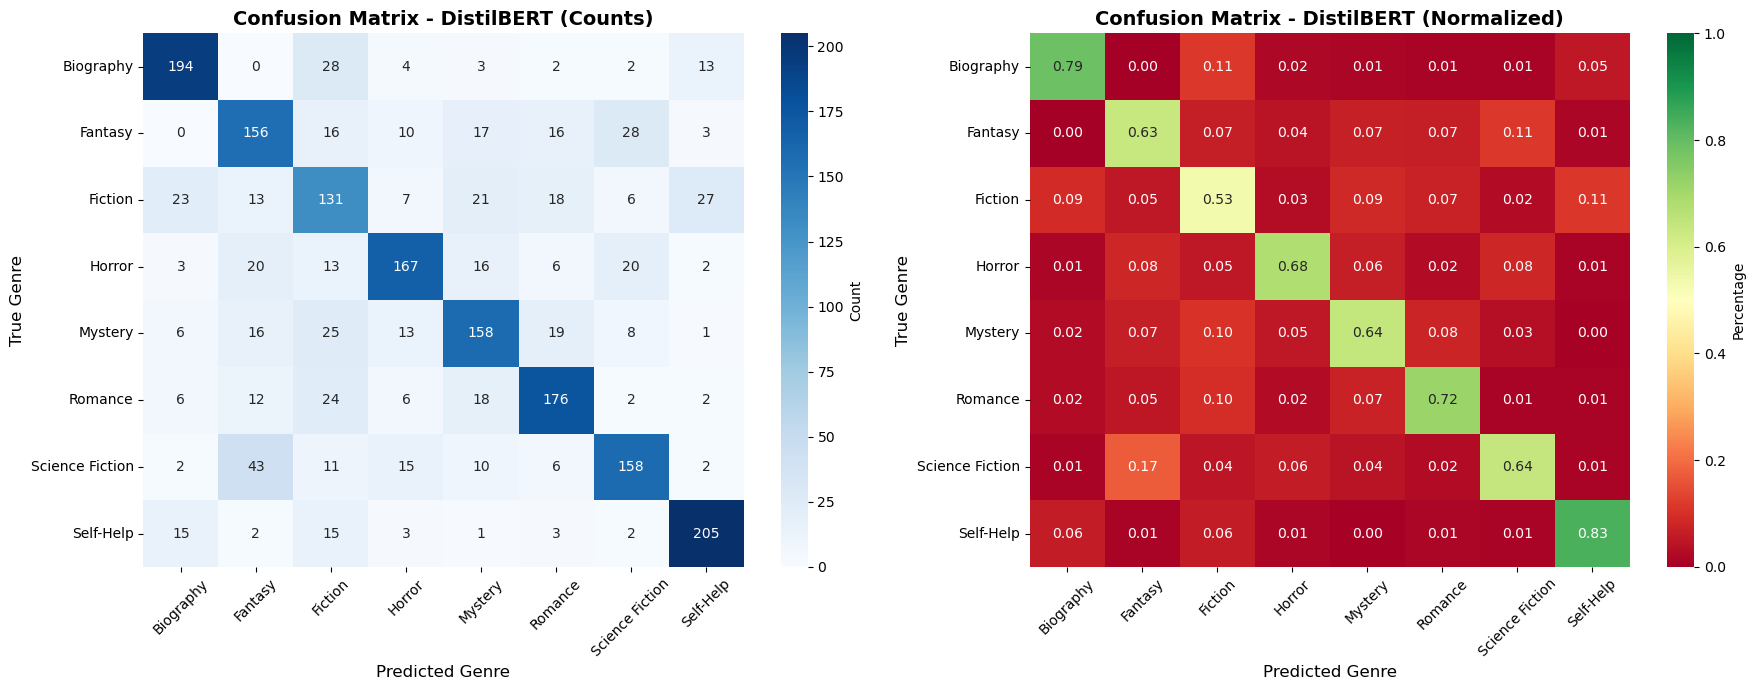

In [12]:
print("="*80)
print("CONFUSION MATRIX")
print("="*80)

# Calculating confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Creating figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES,
            cbar_kws={'label': 'Count'}, ax=axes[0])
axes[0].set_title('Confusion Matrix - DistilBERT (Counts)', 
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Genre', fontsize=12)
axes[0].set_ylabel('True Genre', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Normalized
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES,
            vmin=0, vmax=1, cbar_kws={'label': 'Percentage'}, ax=axes[1])
axes[1].set_title('Confusion Matrix - DistilBERT (Normalized)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Genre', fontsize=12)
axes[1].set_ylabel('True Genre', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### ROC Curves

ROC CURVE ANALYSIS - DISTILBERT MODEL

Prediction probabilities shape: (1970, 8)
True labels shape: (1970, 8)
Number of test samples: 1970


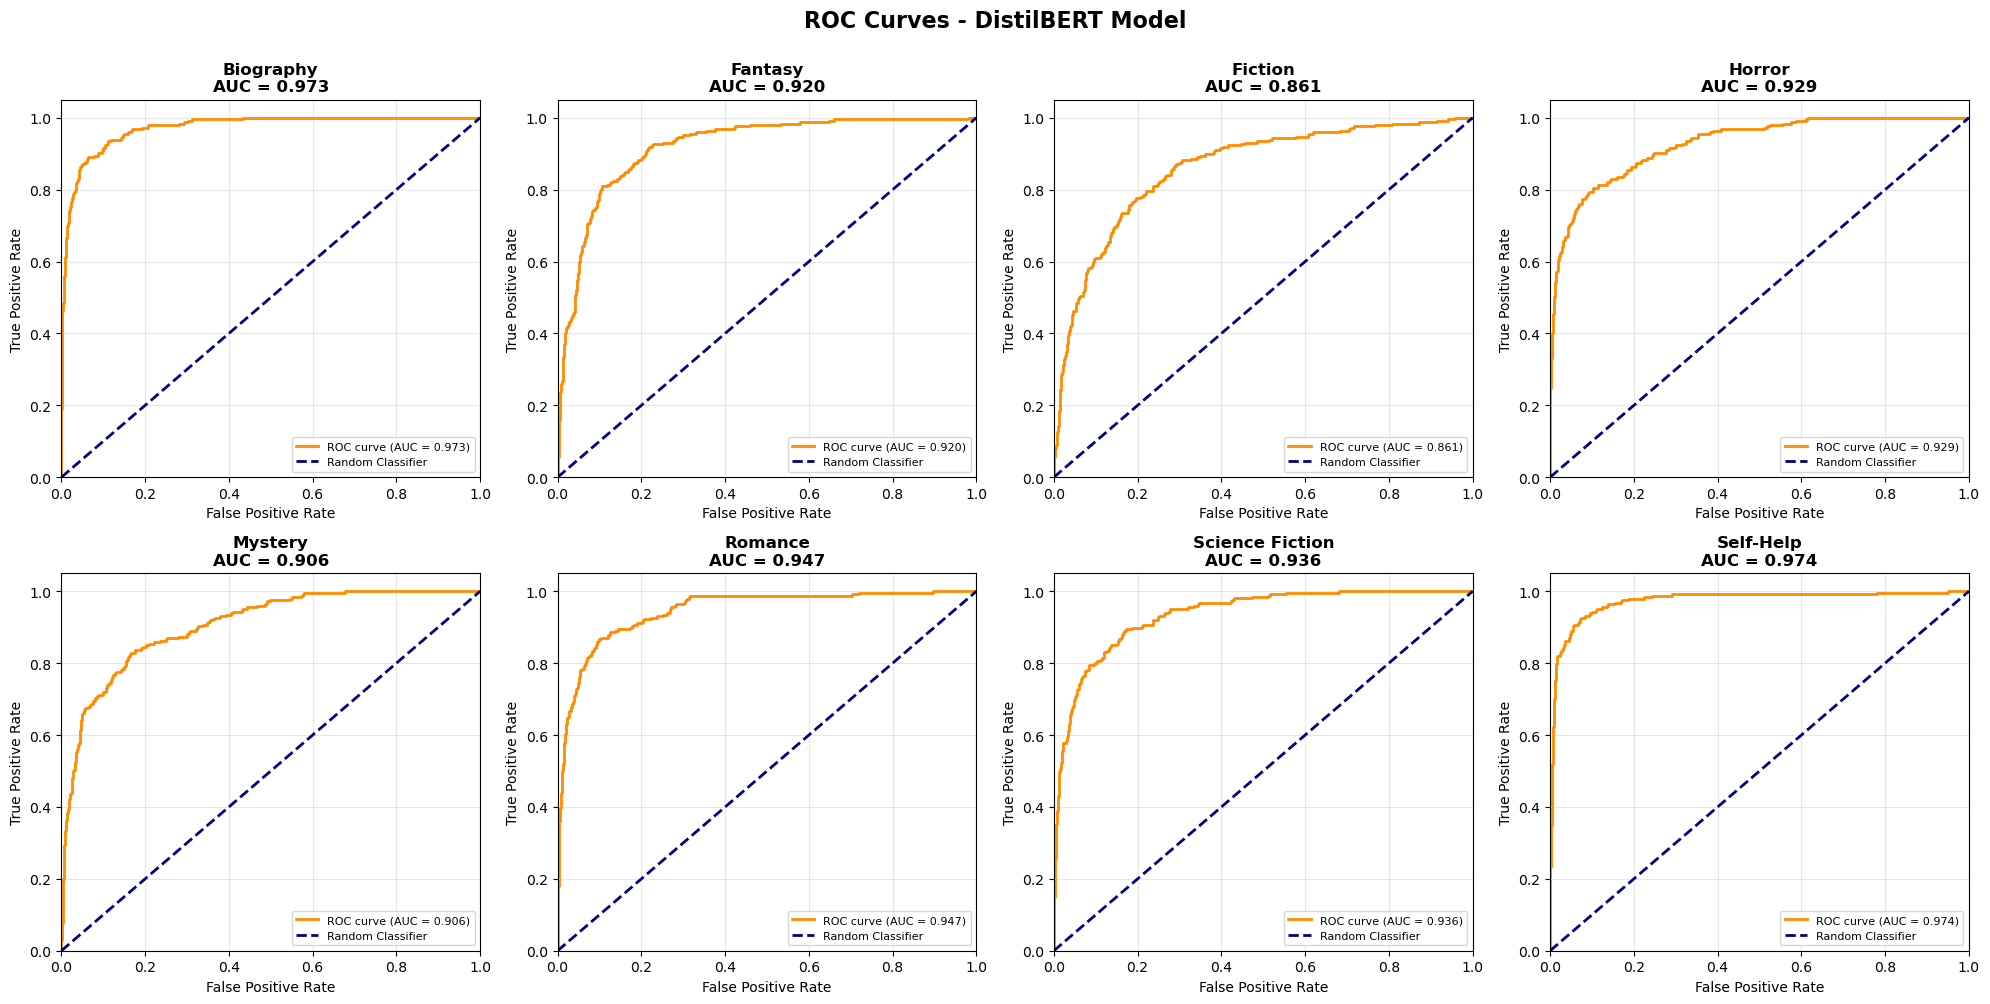


ROC-AUC SCORES BY GENRE - DISTILBERT MODEL
          Genre  AUC Score
      Self-Help   0.974077
      Biography   0.973051
        Romance   0.946758
Science Fiction   0.936010
         Horror   0.928794
        Fantasy   0.920154
        Mystery   0.906473
        Fiction   0.860841

Average AUC: 0.9308

Best performing genre: Self-Help (AUC = 0.9741)
Worst performing genre: Fiction (AUC = 0.8608)
Performance gap: 0.1132


In [15]:
print("="*80)
print("ROC CURVE ANALYSIS - DISTILBERT MODEL")
print("="*80)

# Genre names
GENRE_NAMES = ['Biography', 'Fantasy', 'Fiction', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Self-Help']


# Convert logits to probabilities using softmax
y_pred_proba_distilbert = softmax(predictions.predictions, axis=1)

# Getting true labels
y_true = test_labels

# Binarizing the output for ROC curve calculation
y_test_bin = label_binarize(y_true, classes=range(len(GENRE_NAMES)))

print(f"\nPrediction probabilities shape: {y_pred_proba_distilbert.shape}")
print(f"True labels shape: {y_test_bin.shape}")
print(f"Number of test samples: {len(y_true)}")

# Calculating ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(GENRE_NAMES)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_distilbert[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting ROC curves for each genre
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(len(GENRE_NAMES)):
    axes[i].plot(fpr[i], tpr[i], color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {roc_auc[i]:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate', fontsize=10)
    axes[i].set_ylabel('True Positive Rate', fontsize=10)
    axes[i].set_title(f'{GENRE_NAMES[i]}\nAUC = {roc_auc[i]:.3f}', 
                      fontsize=12, fontweight='bold')
    axes[i].legend(loc="lower right", fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('ROC Curves - DistilBERT Model', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Summary of AUC scores
print("\n" + "="*80)
print("ROC-AUC SCORES BY GENRE - DISTILBERT MODEL")
print("="*80)
auc_df = pd.DataFrame({
    'Genre': GENRE_NAMES,
    'AUC Score': [roc_auc[i] for i in range(len(GENRE_NAMES))]
}).sort_values('AUC Score', ascending=False)

print(auc_df.to_string(index=False))
print(f"\nAverage AUC: {np.mean([roc_auc[i] for i in range(len(GENRE_NAMES))]):.4f}")
print("="*80)

#  Showing comparison of best and worst performing genres
best_genre_idx = np.argmax([roc_auc[i] for i in range(len(GENRE_NAMES))])
worst_genre_idx = np.argmin([roc_auc[i] for i in range(len(GENRE_NAMES))])

print(f"\nBest performing genre: {GENRE_NAMES[best_genre_idx]} (AUC = {roc_auc[best_genre_idx]:.4f})")
print(f"Worst performing genre: {GENRE_NAMES[worst_genre_idx]} (AUC = {roc_auc[worst_genre_idx]:.4f})")
print(f"Performance gap: {roc_auc[best_genre_idx] - roc_auc[worst_genre_idx]:.4f}")
print("="*80)

### Precision Recall Curves 

PRECISION-RECALL CURVE ANALYSIS - DISTILBERT MODEL


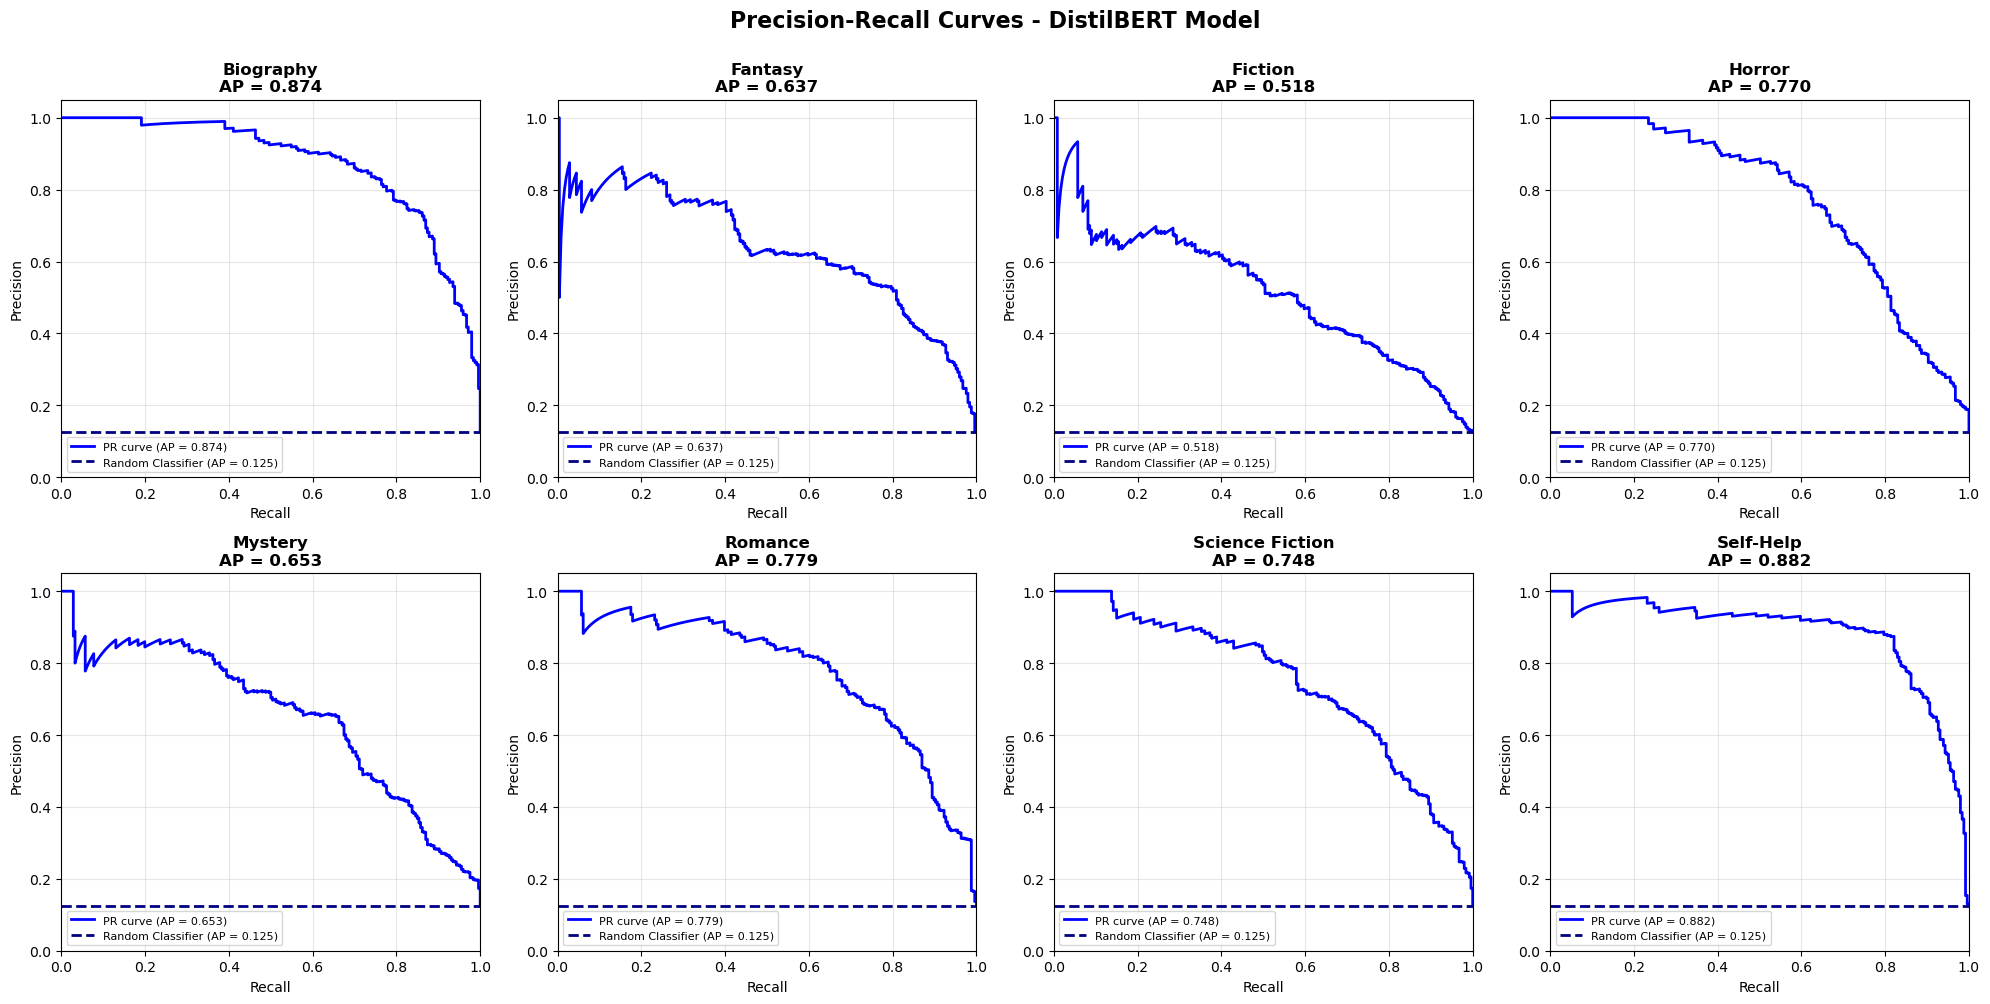


AVERAGE PRECISION SCORES BY GENRE - DISTILBERT MODEL
          Genre  Average Precision
      Self-Help           0.881984
      Biography           0.874228
        Romance           0.778595
         Horror           0.769903
Science Fiction           0.747831
        Mystery           0.652899
        Fantasy           0.637140
        Fiction           0.518219

Mean Average Precision (mAP): 0.7326
Random Baseline (1/num_classes): 0.1250


In [17]:
print("="*80)
print("PRECISION-RECALL CURVE ANALYSIS - DISTILBERT MODEL")
print("="*80)

# Calculate Precision-Recall curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

for i in range(len(GENRE_NAMES)):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_distilbert[:, i])
    avg_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_proba_distilbert[:, i])

# Plot Precision-Recall curves for each genre
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(len(GENRE_NAMES)):
    axes[i].plot(recall[i], precision[i], color='blue', lw=2, 
                 label=f'PR curve (AP = {avg_precision[i]:.3f})')
    axes[i].axhline(y=1/len(GENRE_NAMES), color='navy', lw=2, linestyle='--', 
                    label=f'Random Classifier (AP = {1/len(GENRE_NAMES):.3f})')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('Recall', fontsize=10)
    axes[i].set_ylabel('Precision', fontsize=10)
    axes[i].set_title(f'{GENRE_NAMES[i]}\nAP = {avg_precision[i]:.3f}', 
                      fontsize=12, fontweight='bold')
    axes[i].legend(loc="lower left", fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('Precision-Recall Curves - DistilBERT Model', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Summary of Average Precision scores
print("\n" + "="*80)
print("AVERAGE PRECISION SCORES BY GENRE - DISTILBERT MODEL")
print("="*80)
ap_df = pd.DataFrame({
    'Genre': GENRE_NAMES,
    'Average Precision': [avg_precision[i] for i in range(len(GENRE_NAMES))]
}).sort_values('Average Precision', ascending=False)

print(ap_df.to_string(index=False))
print(f"\nMean Average Precision (mAP): {np.mean([avg_precision[i] for i in range(len(GENRE_NAMES))]):.4f}")
print(f"Random Baseline (1/num_classes): {1/len(GENRE_NAMES):.4f}")
print("="*80)




### Word Cloud-Frequency Based

WORD ANALYSIS - DISTILBERT MODEL

Total test samples: 1970
Correctly classified: 1345 (68.27%)
Unique words after filtering: 12167


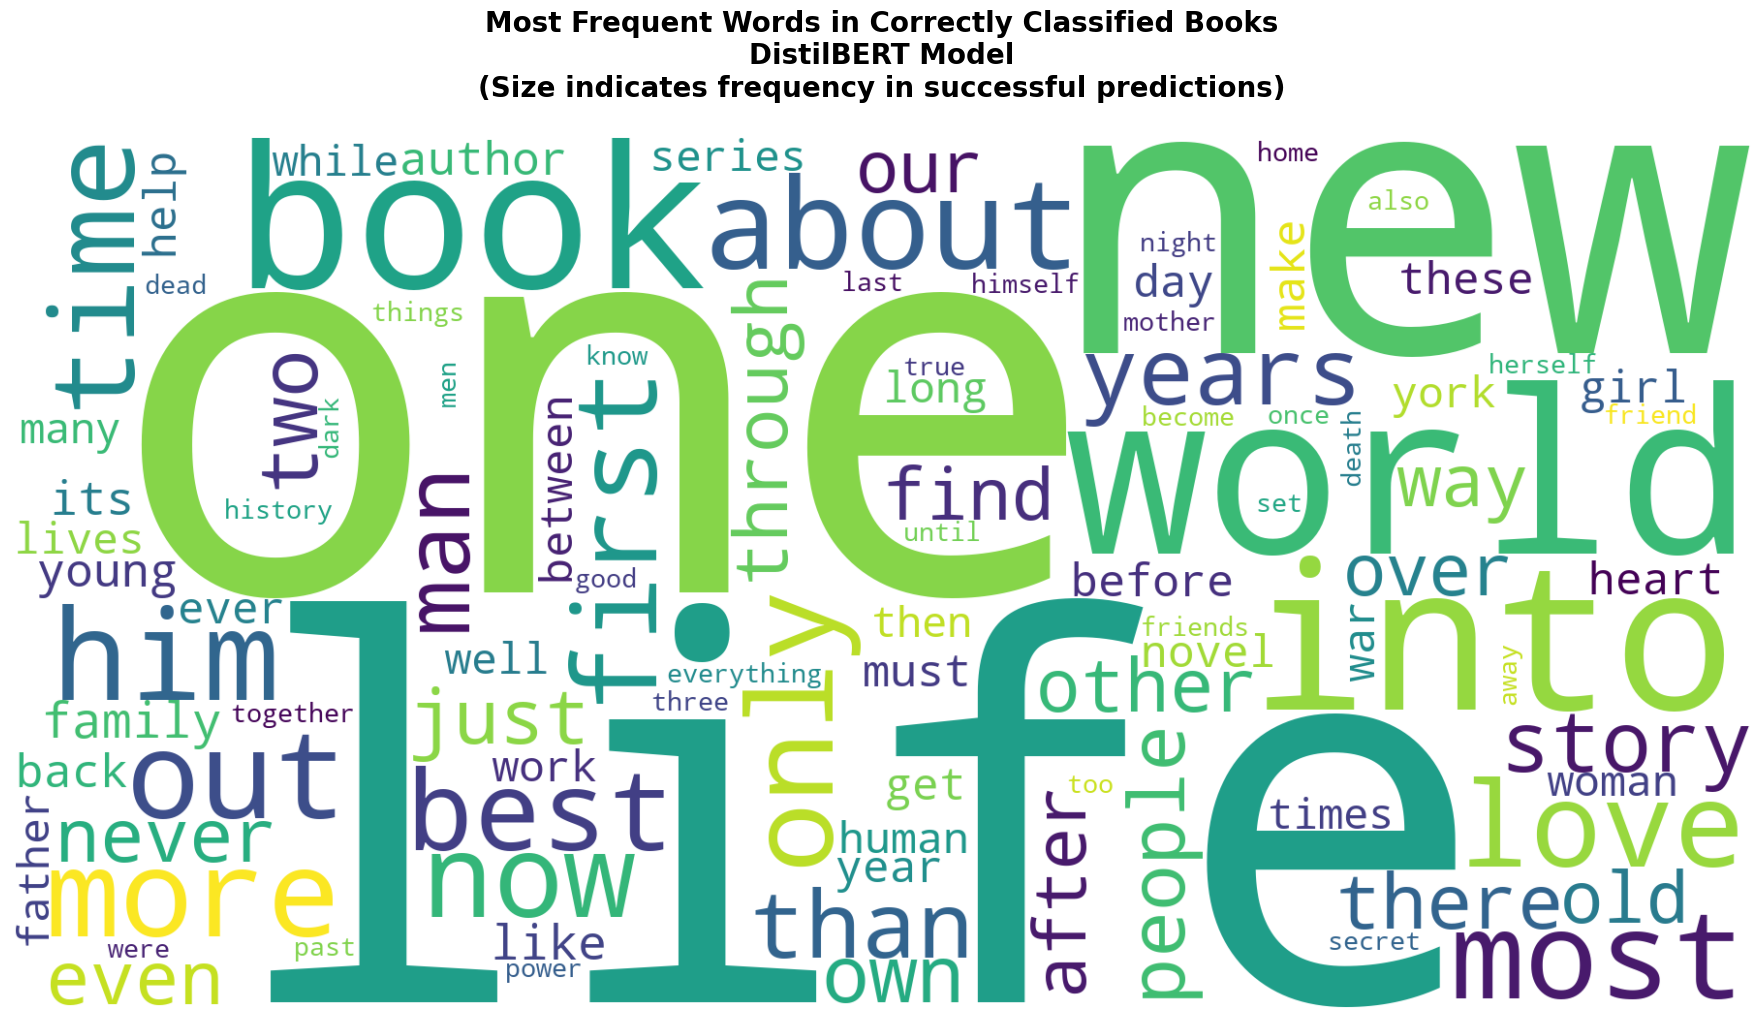


TOP 30 MOST FREQUENT WORDS
Rank   Word                      Frequency       Percentage     
--------------------------------------------------------------------------------
1      one                       737             0.70%
2      life                      699             0.67%
3      new                       580             0.55%
4      world                     503             0.48%
5      into                      442             0.42%
6      book                      434             0.41%
7      about                     389             0.37%
8      him                       387             0.37%
9      out                       370             0.35%
10     more                      369             0.35%
11     most                      367             0.35%
12     love                      344             0.33%
13     only                      336             0.32%
14     now                       330             0.31%
15     time                      323             0.31%
1

In [19]:


print("="*80)
print("WORD ANALYSIS - DISTILBERT MODEL")
print("="*80)

# Finding correctly classified samples
correct_predictions = (y_pred == y_true)

print(f"\nTotal test samples: {len(y_true)}")
print(f"Correctly classified: {np.sum(correct_predictions)} ({np.sum(correct_predictions)/len(y_true)*100:.2f}%)")

# Extracting words from correctly classified samples
all_input_ids = []
for i, sample in enumerate(test_dataset):
    if correct_predictions[i]:
        all_input_ids.extend(sample['input_ids'])

# Converting token IDs to words and count frequency
word_counts = Counter()
for token_id in all_input_ids:
    token = tokenizer.decode([token_id]).strip()
    if token and len(token) > 2:
        word_counts[token] += 1

# Defining  words to exclude
special_tokens = {'[CLS]', '[SEP]', '[PAD]', '[UNK]', '[MASK]', 'cls', 'sep', 'pad', 'unk', 'mask'}
stop_words = {
    'the', 'and', 'of', 'to', 'in', 'is', 'it', 'that', 'for', 'with',
    'as', 'on', 'was', 'at', 'by', 'an', 'be', 'this', 'which', 'or',
    'from', 'but', 'not', 'are', 'his', 'her', 'they', 'have', 'has',
    'had', 'will', 'would', 'can', 'could', 'should', 'may', 'might',
    'you', 'your', 'he', 'she', 'we', 'them', 'their', 'what',
    'who', 'when', 'where', 'why', 'how', 'all', 'each', 'every', 'some',
    'been', 'being', 'both', 'did', 'do', 'does', 'doing', 'down'
}

# Filtering words
filtered_word_counts = {}
for word, count in word_counts.items():
    word_lower = word.lower()
    if (word_lower not in special_tokens and 
        word_lower not in stop_words and 
        len(word) > 2 and
        word.isalpha()):
        filtered_word_counts[word] = count

print(f"Unique words after filtering: {len(filtered_word_counts)}")

# Creating word cloud
if filtered_word_counts:
    wordcloud = WordCloud(
        width=1800, 
        height=900,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5,
        min_font_size=10,
        max_words=100,
        collocations=False
    ).generate_from_frequencies(filtered_word_counts)
    
    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Frequent Words in Correctly Classified Books\nDistilBERT Model\n(Size indicates frequency in successful predictions)', 
              fontsize=20, fontweight='bold', pad=30)
    plt.tight_layout(pad=0)
    plt.show()
    
    # Printing top 30 words
    print("\n" + "="*80)
    print("TOP 30 MOST FREQUENT WORDS")
    print("="*80)
    print(f"{'Rank':<6} {'Word':<25} {'Frequency':<15} {'Percentage':<15}")
    print("-"*80)
    
    sorted_words = sorted(filtered_word_counts.items(), key=lambda x: x[1], reverse=True)
    total_words = sum(filtered_word_counts.values())
    
    for i, (word, count) in enumerate(sorted_words[:30], 1):
        percentage = (count / total_words) * 100
        print(f"{i:<6} {word:<25} {count:<15} {percentage:.2f}%")
    
    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"Total words analyzed: {total_words:,}")
    print(f"Unique words: {len(filtered_word_counts):,}")
    print(f"Top 30 words represent: {sum([count for _, count in sorted_words[:30]]) / total_words * 100:.2f}% of all words")
    print("="*80)

else:
    print("\nError: No words found after filtering.")

### Top Words Bar Chart 


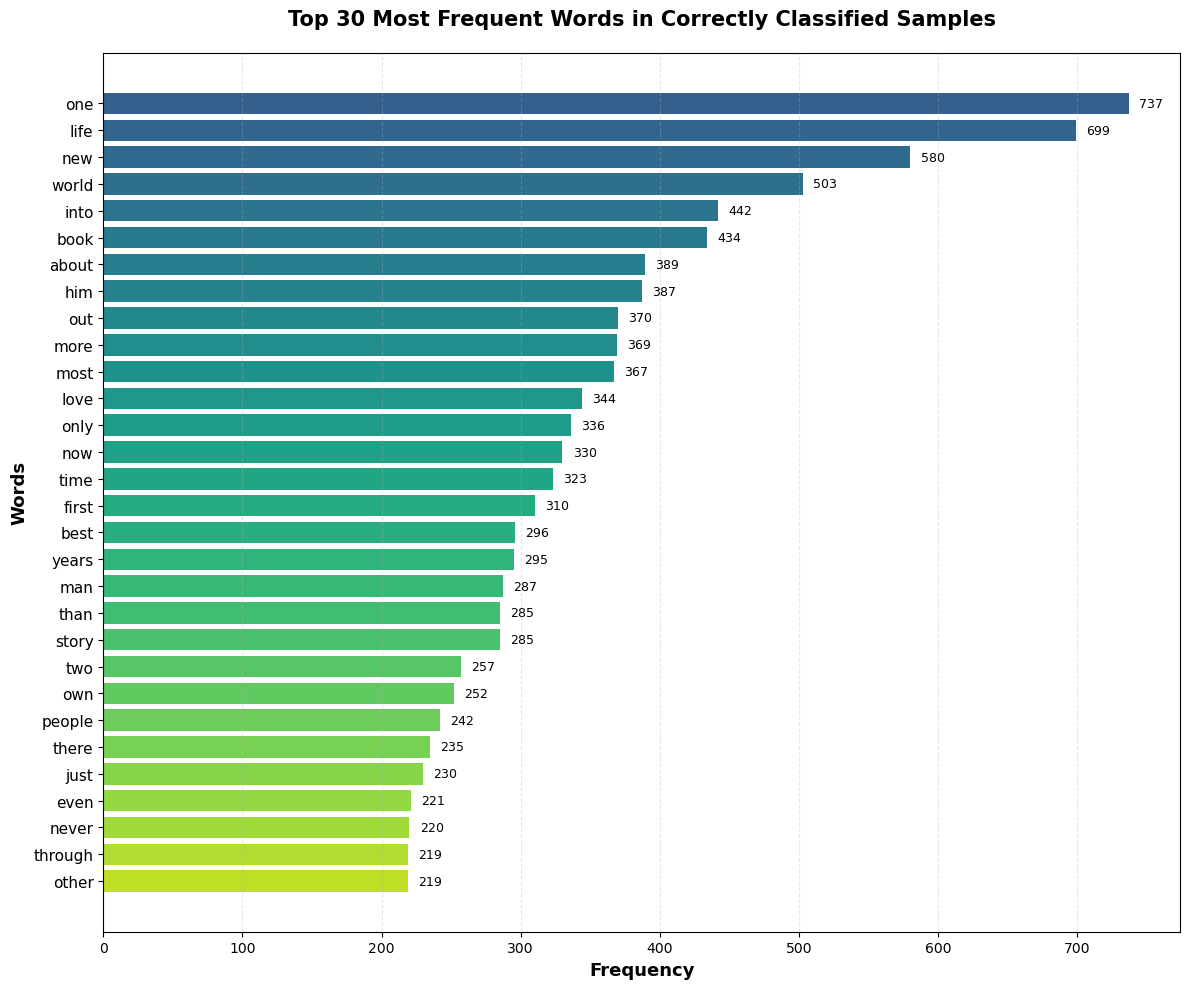

In [22]:
top_words = [word for word, count in sorted_words[:30]]
top_counts = [count for word, count in sorted_words[:30]]

plt.figure(figsize=(12, 10))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_words)))


bars = plt.barh(range(len(top_words)), top_counts, color=colors)

plt.yticks(range(len(top_words)), top_words, fontsize=11)
plt.xlabel('Frequency', fontsize=13, fontweight='bold')
plt.ylabel('Words', fontsize=13, fontweight='bold')

plt.title(
    'Top 30 Most Frequent Words in Correctly Classified Samples',
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.gca().invert_yaxis()

for bar, value in zip(bars, top_counts):
    plt.text(
        value + max(top_counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value}',
        va='center',
        fontsize=9
    )

plt.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


### Genre Wise Word Cloud

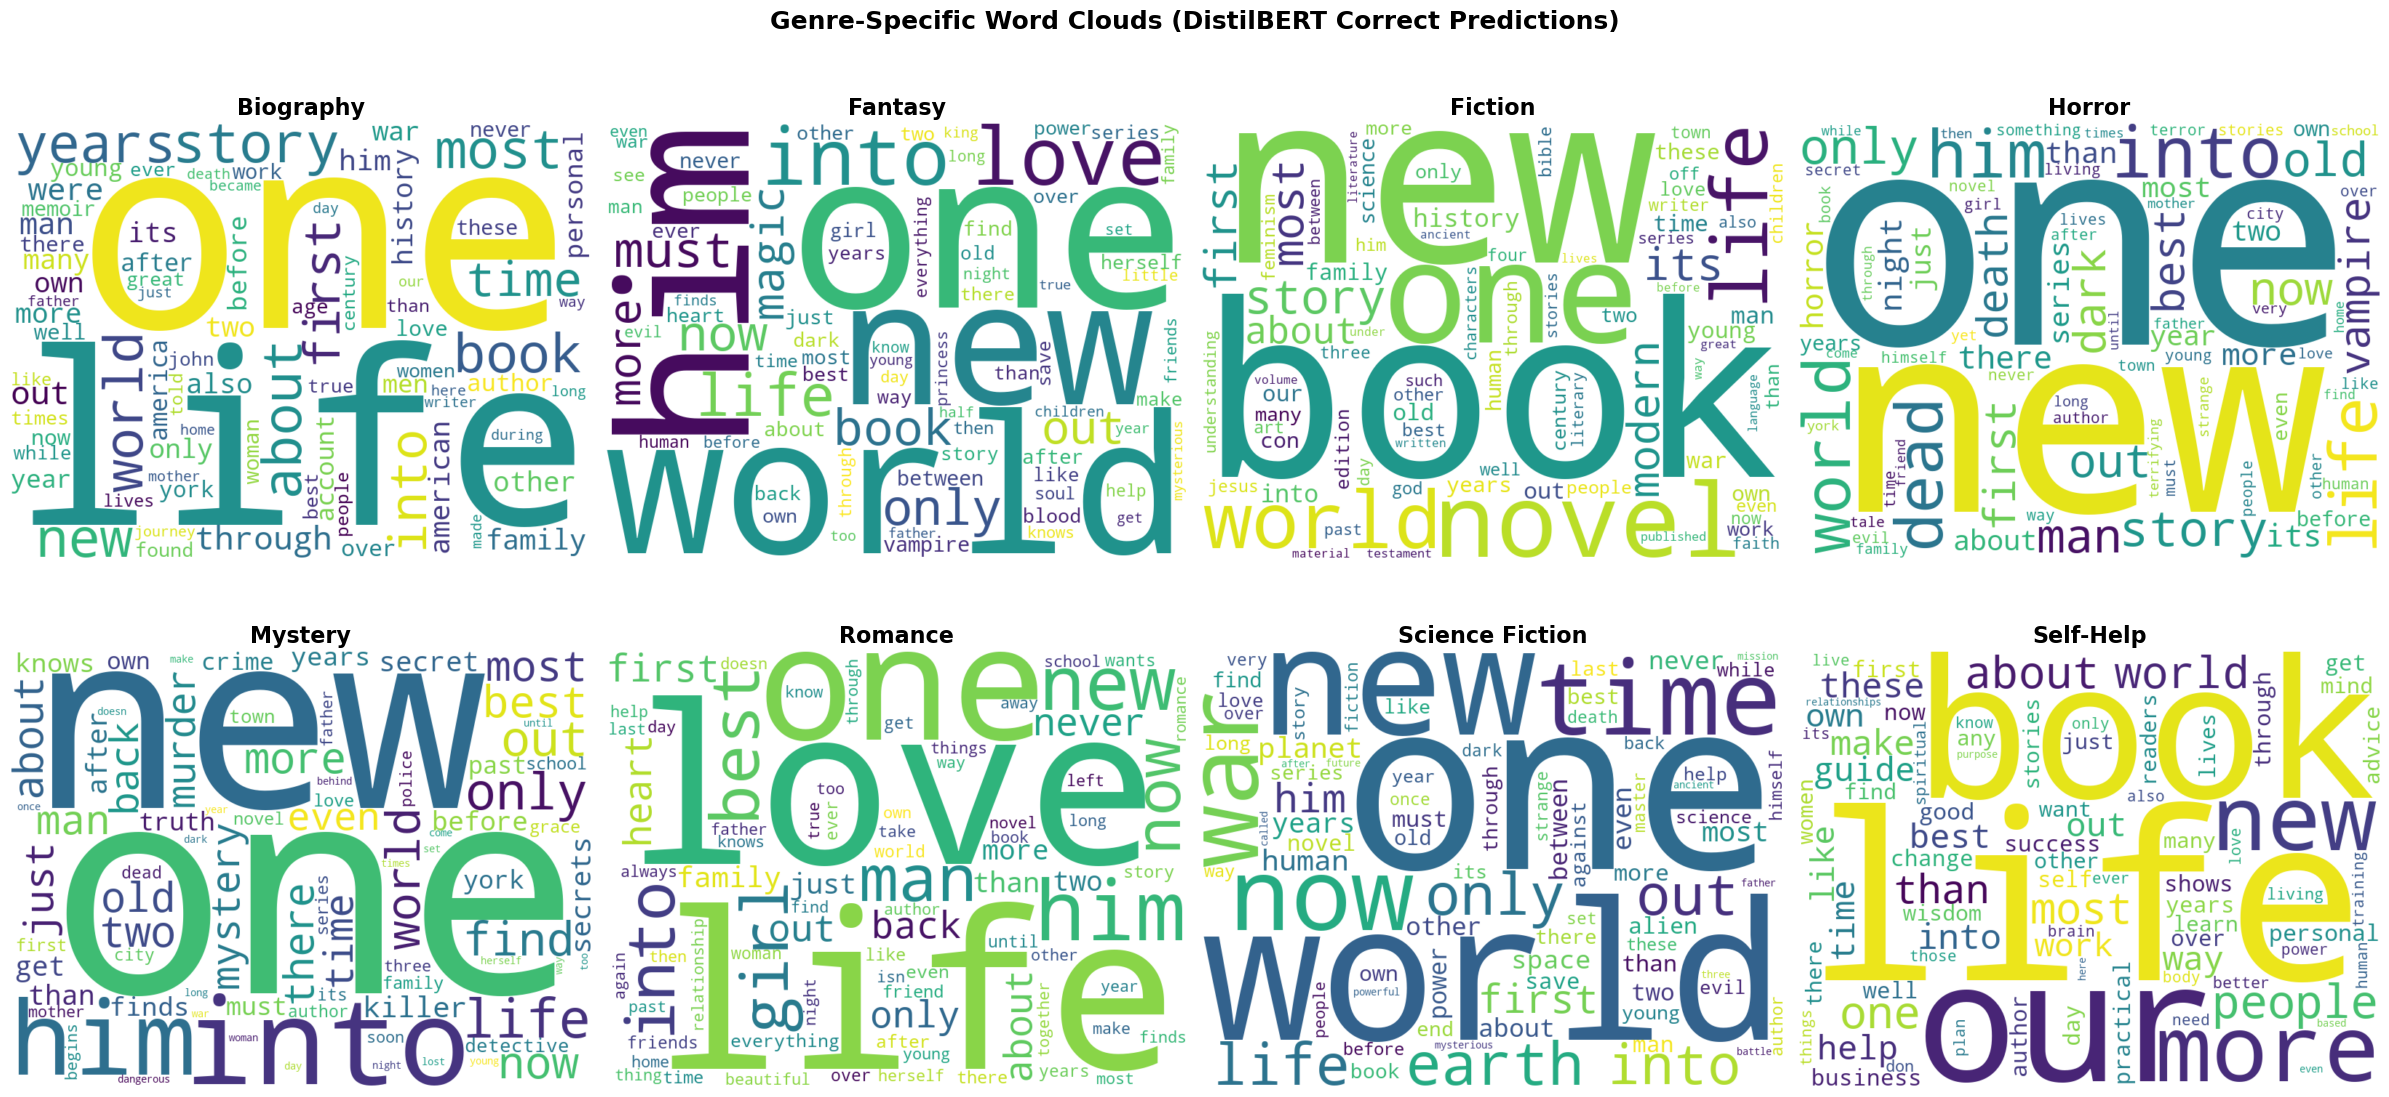

In [23]:

# Converting to numpy for easy indexing
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

genre_names = ['Biography', 'Fantasy', 'Fiction', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Self-Help']


for gi, genre in enumerate(genre_names):

    # Identifying correctly classified samples for this genre
    genre_mask = (y_true_arr == gi) & (y_pred_arr == gi)
    genre_indices = np.where(genre_mask)[0]

    # Collecting all token IDs for this genre
    token_ids = []
    for idx in genre_indices:
        token_ids.extend(test_dataset[idx]['input_ids'])

    # Count meaningful words
    genre_counts = Counter()
    for tid in token_ids:
        word = tokenizer.decode([tid]).strip()
        if word and word.isalpha() and len(word) > 2:
            wl = word.lower()
            if wl not in stop_words and wl not in special_tokens:
                genre_counts[wl] += 1

    # Building word cloud
    if genre_counts:
        wc = WordCloud(
            width=800,
            height=600,
            background_color='white',
            colormap='viridis',
            max_words=80,
            collocations=False
        ).generate_from_frequencies(genre_counts)

        axes[gi].imshow(wc, interpolation='bilinear')
        axes[gi].axis('off')
        axes[gi].set_title(genre, fontsize=16, fontweight='bold')
    else:
        axes[gi].text(0.5, 0.5, "No valid words", ha='center')
        axes[gi].axis('off')

plt.suptitle(
    'Genre-Specific Word Clouds (DistilBERT Correct Predictions)',
    fontsize=18, fontweight='bold', y=0.98
)

plt.tight_layout()
plt.show()
